# Utils

In [1]:
def euclidean_distance(x, y):
    return np.sum((x - y) ** 2)

# K Nearest Neighbours

In [2]:
import numpy as np
# from collections import Counter

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        
        k_nearest_indeces = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_nearest_indeces]

        # labels_counts = Counter(k_nearest_labels)
        labels_counts = {label: k_nearest_labels.count(label) for label in set(k_nearest_labels)}
        most_common_label = max(labels_counts, key=labels_counts.get)

        return most_common_label

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Text(0.5, 0, 'Our prediction classfication')

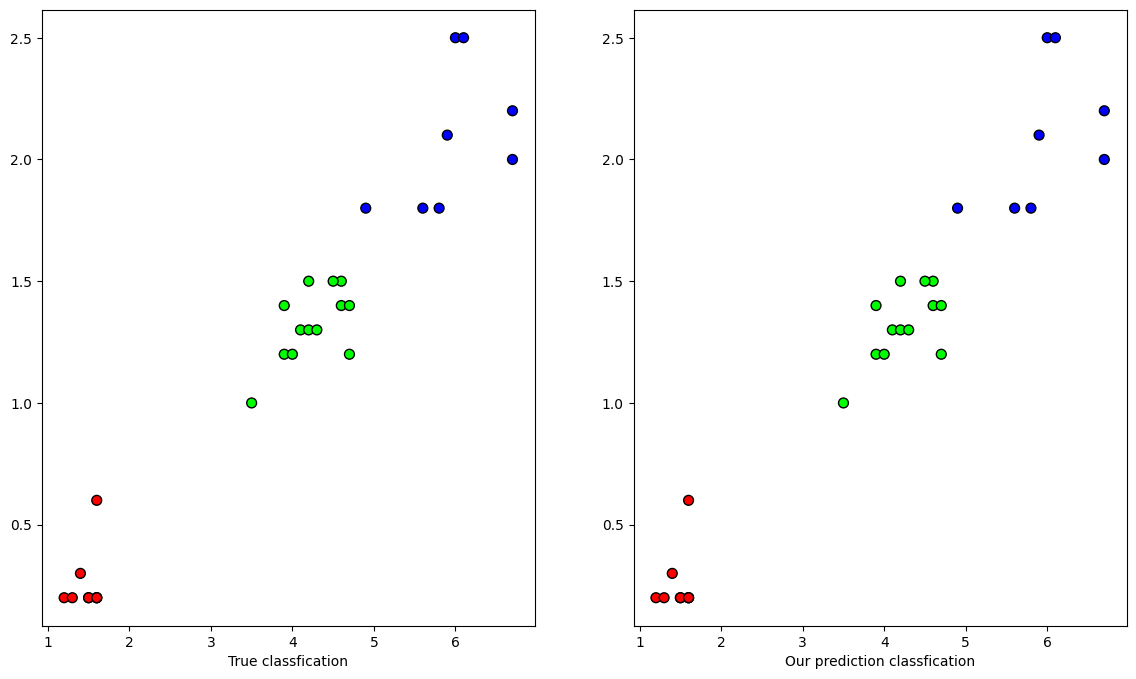

In [12]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

print(iris.DESCR)

fig, axs = plt.subplots(1, 2, figsize=(14,8))

axs[0].scatter(X_test[:,2], X_test[:,3], c=y_test, cmap=cmap, edgecolor='k', s=50)
axs[0].set_xlabel('True classfication')

clf = KNN()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

axs[1].scatter(X_test[:,2], X_test[:,3], c=y_pred, cmap=cmap, edgecolor='k', s=50)
axs[1].set_xlabel('Our prediction classfication')

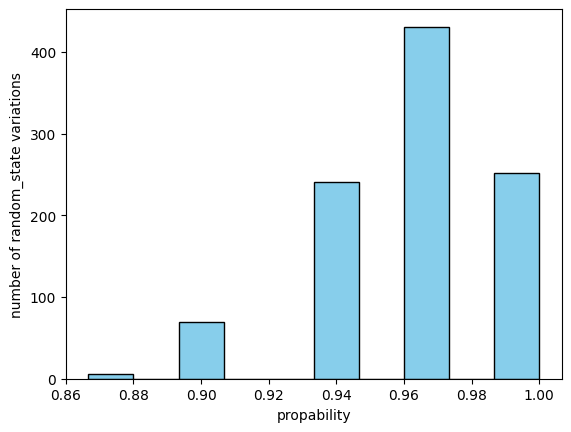

In [13]:
accs = []
for rs in range(0, 10000, 10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=rs
    )
    knn = KNN(k=3)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = np.mean(y_pred == y_test)
    accs.append(acc)

plt.hist(accs, color='skyblue', edgecolor='k')
plt.ylabel('number of random_state variations')
plt.xlabel('propability')
plt.show()

# Linear Regression

In [5]:
import numpy as np

class LinearRegression:
    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            y_pred = X @ self.weights + self.bias
            
            dw = X.T @ (y_pred - y) / n_samples
            db = np.sum(y_pred - y) / n_samples
            
            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db
        
    def predict(self, X):
        y_pred = X @ self.weights + self.bias
        return y_pred

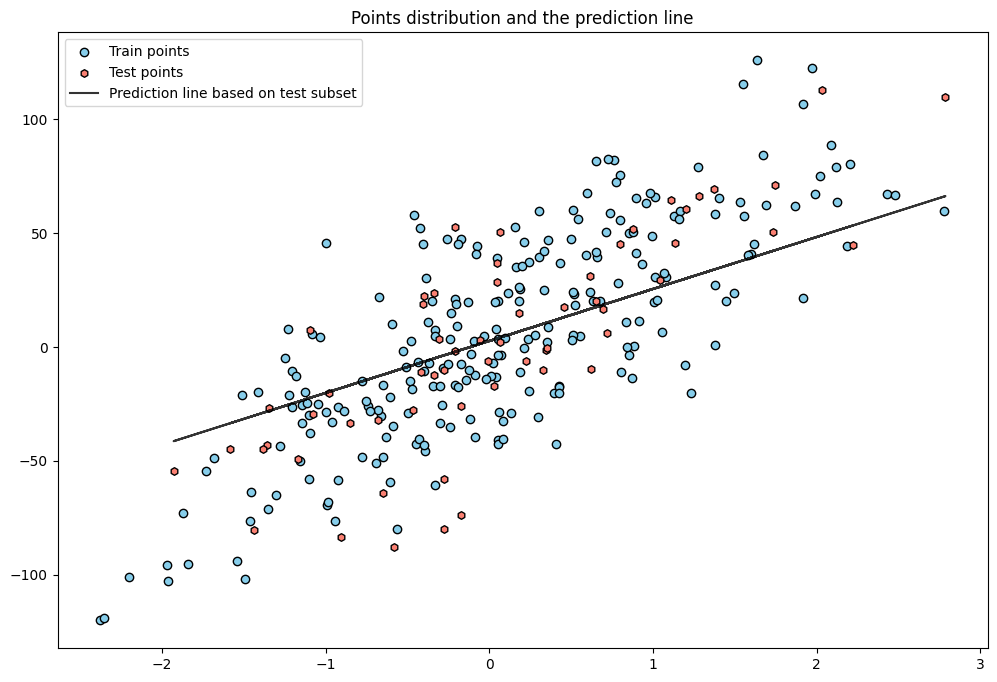

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

X, y = datasets.make_regression(
    n_samples=300, n_features=1, noise=30, random_state=4
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

regression = LinearRegression()
regression.fit(X_train, y_train)
y_pred = regression.predict(X_test)

fig, ax = plt.subplots(figsize=(12,8))
plt.scatter(X_train[:,0], y_train, color='skyblue', marker='o', edgecolors='k', label='Train points')
plt.scatter(X_test[:,0], y_test, color='salmon', marker='h', edgecolors='k', s=30, label='Test points')
plt.plot(X_test, y_pred, color='k', alpha=0.8, label='Prediction line based on test subset')
plt.title('Points distribution and the prediction line')
plt.legend()
plt.show()

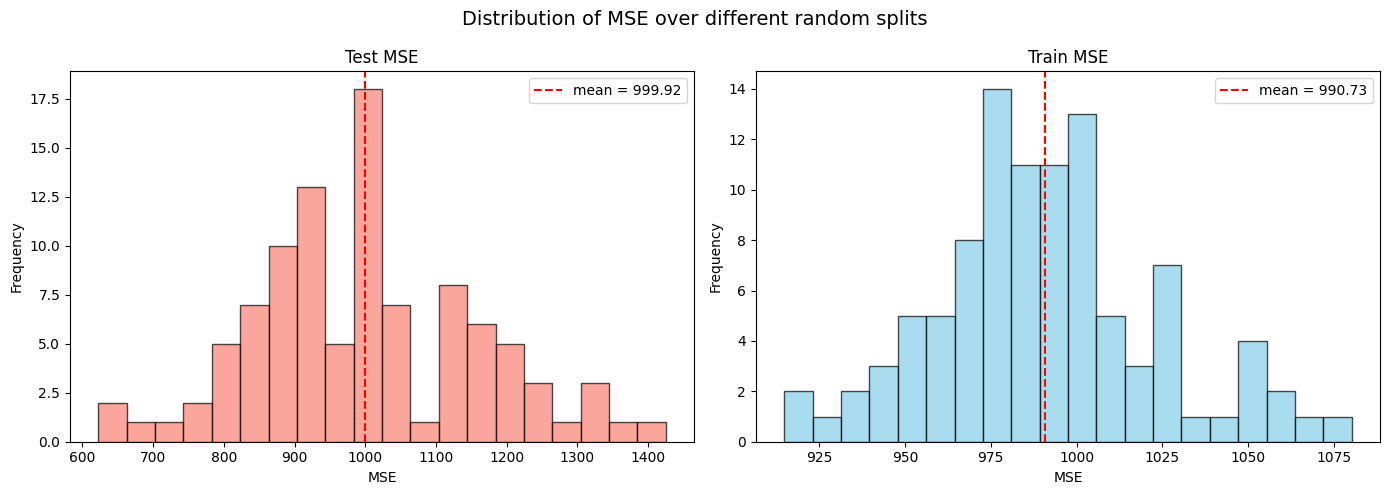

Средний MSE на тесте: 999.92 ± 160.99
Средний MSE на обучении: 990.73 ± 32.14
Невязка (Test - Train): 9.19


In [7]:
mses_test = []
mses_train = []

random_states = range(0, 10000, 100)

for rs in random_states:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=rs
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred_test = model.predict(X_test)
    mse_test = np.mean((y_test - y_pred_test) ** 2)
    mses_test.append(mse_test)
    
    y_pred_train = model.predict(X_train)
    mse_train = np.mean((y_train - y_pred_train) ** 2)
    mses_train.append(mse_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(mses_test, bins=20, edgecolor='k', alpha=0.7, color='salmon')
ax1.axvline(np.mean(mses_test), color='red', linestyle='--', label=f'mean = {np.mean(mses_test):.2f}')
ax1.set_xlabel('MSE')
ax1.set_ylabel('Frequency')
ax1.set_title('Test MSE')
ax1.legend()

ax2.hist(mses_train, bins=20, edgecolor='k', alpha=0.7, color='skyblue')
ax2.axvline(np.mean(mses_train), color='red', linestyle='--', label=f'mean = {np.mean(mses_train):.2f}')
ax2.set_xlabel('MSE')
ax2.set_ylabel('Frequency')
ax2.set_title('Train MSE')
ax2.legend()

fig.suptitle('Distribution of MSE over different random splits', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Средний MSE на тесте: {np.mean(mses_test):.2f} ± {np.std(mses_test):.2f}")
print(f"Средний MSE на обучении: {np.mean(mses_train):.2f} ± {np.std(mses_train):.2f}")
print(f"Невязка (Test - Train): {np.mean(mses_test) - np.mean(mses_train):.2f}")

# Logistic Regression

In [57]:
import numpy as np

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

class LogisticRegression():

    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_predictions = X @ self.weights + self.bias
            y_pred = sigmoid(linear_predictions)

            dw = X.T @ (y_pred - y) / n_samples
            db = np.sum(y_pred - y) / n_samples

            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db

    def predict(self, X):
        linear_predictions = X @ self.weights + self.bias
        y_pred = sigmoid(linear_predictions)
        labels = [0 if y < 0.5 else 1 for y in y_pred]
        return labels

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

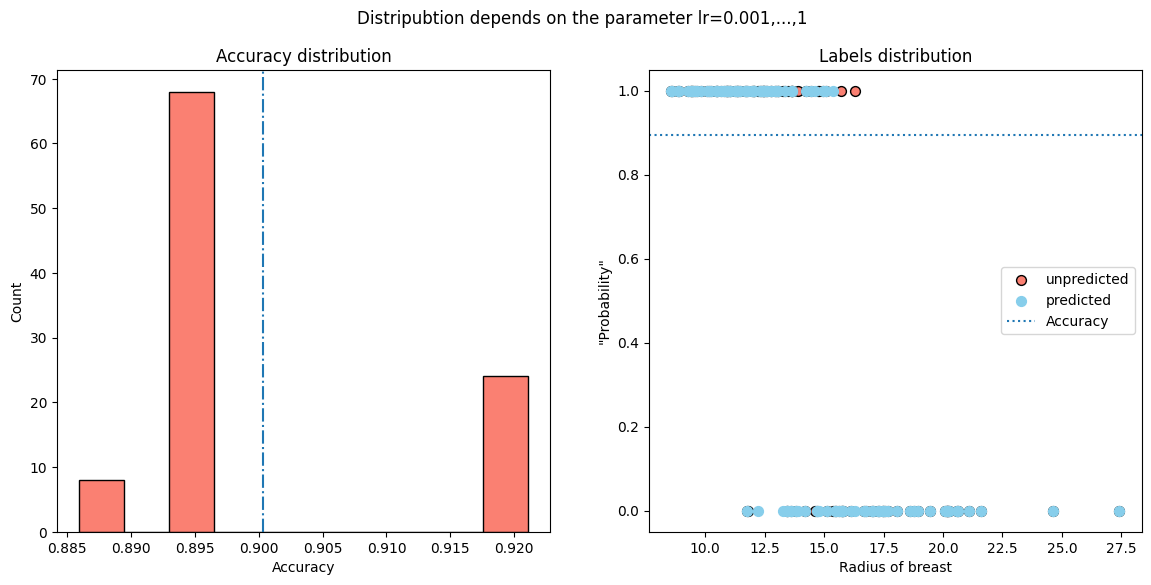

In [108]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

print(bc.DESCR)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

accs = []
for d in range(1, 1000, 10):
    clf = LogisticRegression(lr = 1 / d)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    acc = np.sum(y_pred == y_test) / len(y_test)
    accs.append(acc)

mean = sum(accs) / len(accs)
ax1.hist(accs, bins=10, color='salmon', edgecolor='k')
ax1.axvline(mean, linestyle='-.', label='Mean accuracy')

ax1.set_title('Accuracy distribution')
ax1.set_ylabel('Count')
ax1.set_xlabel('Accuracy')

ax2.set_title('Labels distribution')
ax2.scatter(X_test[:, 0], y_test, color='salmon', edgecolor='k', s=50, label='unpredicted')
ax2.scatter(X_test[:, 0], y_pred, color='skyblue', s=50, label='predicted')
ax2.axhline(acc, linestyle=':', label='Accuracy')
ax2.set_ylabel('"Probability"')
ax2.set_xlabel('Radius of breast')

fig.suptitle('Distripubtion depends on the parameter lr=0.001,...,1')
plt.legend()
plt.show()

# Decision Trees

In [8]:
import numpy as np
from collections import Counter
    

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def  __init__(self, min_samples_split=2, min_impurity_decrease=0.0, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.min_impurity_decrease = min_impurity_decrease
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None
j
    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # check the stopping criteria
        if (depth >= self.max_depth 
            or n_labels == 1 
            or n_samples < self.min_samples_split):
            
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        feature_idxs = np.random.choice(n_features, self.n_features, replace=False)
        
        # find the best split
        best_feature, best_threshold, best_gain = self._best_split(X, y, feature_idxs)

        if best_gain < self.min_impurity_decrease:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
            
        # create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feature], best_threshold)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feature, best_threshold, left, right)
            
    def _best_split(self, X, y, feature_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feature_idx in feature_idxs:
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                # calculate the information gain
                gain = self._information_gain(y, X_column, threshold)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feature_idx
                    split_threshold = threshold

        return split_idx, split_threshold, best_gain

    def _information_gain(self, y, X_column, threshold):
        # parent entropy
        parent_entropy = self._entropy(y)

        # create children
        left_idxs, right_idxs = self._split(X_column, threshold)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # calculate the avg. weighted entropy of children 
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l/n) * e_l + (n_r/n) * e_r

        # calculate the IG
        information_gain = parent_entropy - child_entropy
        return information_gain

    def _split(self, X_column, split_threshold):
        left_idxs = np.argwhere(X_column <= split_threshold).flatten()
        right_idxs = np.argwhere(X_column > split_threshold).flatten()
        return left_idxs, right_idxs
        
    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return - np.sum([p * np.log(p) for p in ps if p > 0])
        # p = hist[hist > 0] / len(y)
        # return - (p @ np.log(p))

    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value
        
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)        

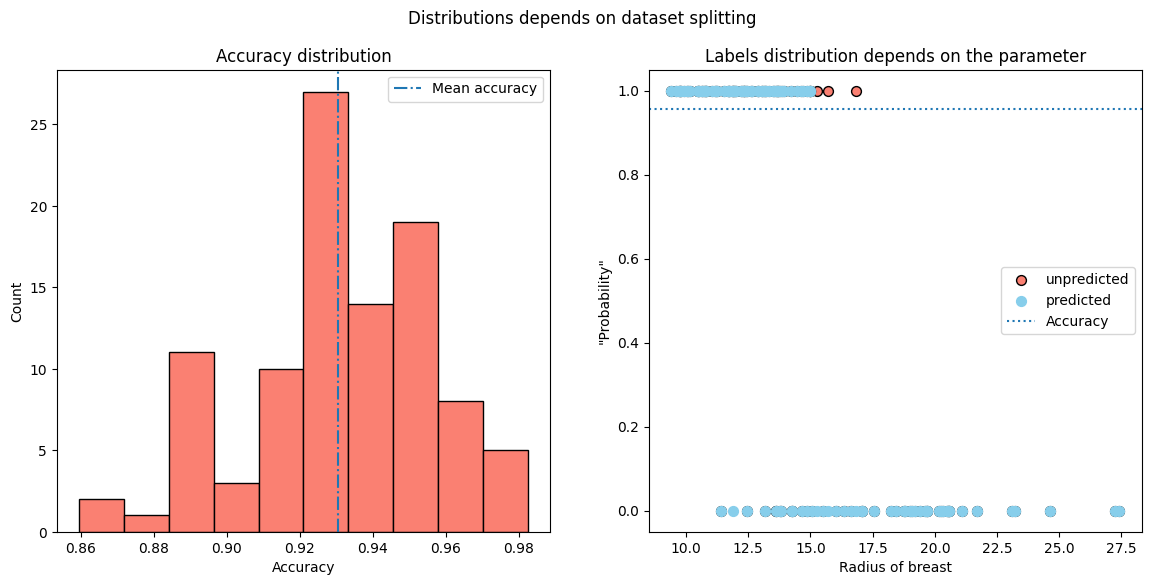

In [3]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

accs = []
for rs in range(1, 1000, 10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=rs
    )
    
    clf = DecisionTree()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    acc = np.sum(y_pred == y_test) / len(y_test)
    accs.append(acc)

mean = sum(accs) / len(accs)
ax1.hist(accs, bins=10, color='salmon', edgecolor='k')
ax1.axvline(mean, linestyle='-.', label='Mean accuracy')

ax1.set_title('Accuracy distribution')
ax1.set_ylabel('Count')
ax1.set_xlabel('Accuracy')
ax1.legend()

ax2.set_title('Labels distribution depends on the parameter')
ax2.scatter(X_test[:, 0], y_test, color='salmon', edgecolor='k', s=50, label='unpredicted')
ax2.scatter(X_test[:, 0], y_pred, color='skyblue', s=50, label='predicted')
ax2.axhline(acc, linestyle=':', label='Accuracy')
ax2.legend()
ax2.set_ylabel('"Probability"')
ax2.set_xlabel('Radius of breast')

fig.suptitle('Distributions depends on dataset splitting')
plt.legend()
plt.show()

In [38]:
from svlearn import DecisionTree
import numpy as np
from collections import Counter


class RandomForest:
    def __init__(self, n_trees=10, max_depth=100, 
            min_samples_split=2, min_impurity_decrease=0.0, n_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_impurity_decrease = min_impurity_decrease
        self.n_features = n_features
        self.trees = []
    
    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            tree = DecisionTree(
                max_depth = self.max_depth,
                min_samples_split = self.min_samples_split,
                min_impurity_decrease = self.min_impurity_decrease,
                n_features = self.n_features
            )
            
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]
        
    def predict(self, X):
        tree_label_pred = np.array([tree.predict(X) for tree in self.trees])
        label_tree_pred = tree_label_pred.T
        y_pred = np.array(
            [self._most_common_label(labels) for labels in label_tree_pred]
        )
        return y_pred
    
    def _most_common_label(self, labels):
        counter = Counter(labels)
        return counter.most_common(1)[0][0]

In [42]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

bc = datasets.load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    bc.data, bc.target, test_size=0.2, random_state=1234
)

In [45]:
accs = []
for value in [0.0, 0.00001, 0.0001, 0.001, 0.01, 0.1]:
    clf1 = RandomForest(min_impurity_decrease=value)
    clf2 = DecisionTree(min_impurity_decrease=value)
    
    clf1.fit(X_train, y_train)
    clf2.fit(X_train, y_train)
    
    y_pred1 = clf1.predict(X_test)
    y_pred2 = clf2.predict(X_test)

    accs.append(
        np.array(np.mean(y_test == y_pred1), np.mean(y_test == y_pred2))
    )

In [47]:
for acc in accs:
    print(acc)

(np.float64(0.9210526315789473), np.float64(0.9122807017543859))
(np.float64(0.9385964912280702), np.float64(0.9122807017543859))
(np.float64(0.8947368421052632), np.float64(0.9385964912280702))
(np.float64(0.8859649122807017), np.float64(0.8947368421052632))
(np.float64(0.6052631578947368), np.float64(0.9210526315789473))
(np.float64(0.6052631578947368), np.float64(0.8771929824561403))


In [ ]:
from svlearn import RandomForest

clf = RandomForest()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(np.mean(y_pred == y_test))

# Naive Bayes

In [14]:
import numpy as np

class NaiveBayes:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._classes = np.unique(y)
        n_classes = len(self._classes)

        # calculate mean, var, and prior for each class
        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)
        self._priors = np.zeros(n_classes, dtype=np.float64)

        for idx, c in enumerate(self._classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis=0)
            self._var[idx, :] = X_c.var(axis=0)
            self._priors[idx] = X_c.shape[0] / float(n_samples)
            
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        posteriors = []

        # calculate posterior probability for each class
        for idx, c in enumerate(self._classes):
            posterior = np.log(self._priors[idx]) + np.sum(np.log(self._pdf(idx, x)))
            posteriors.append(posterior)

        return self._classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        mean = self._mean[class_idx]
        var = self._var[class_idx]
        
        numerator = np.exp(- (x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)

        return numerator / denominator        

In [15]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

X, y = datasets.make_classification(
    n_samples=1000, n_features=10, n_classes=2, random_state=1234
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

clf = NaiveBayes()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(np.mean(y_test == y_pred))

0.93


# Principal Component Analysis

In [17]:
import numpy as np


class PCA:

    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None

    def fit(self, X):
        # mean centering
        self.mean = np.mean(X, axis=0)
        X = X - self.mean

        # covariance (needs samples as columns)
        cov = np.cov(X.T)

        # eigenvectors, eigenvalues
        eigenvectors, eigenvalues = np.linalg.eig(cov)
        eigevectors = eigenvectors.T

        idxs = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[idxs]

        self.components = eigenvectors[:self.n_components]
        
    def transform(self, X):
        X = X - self.mean
        return np.dot(X, self.components.T)
        

(150, 4)
(150, 2)


/tmp/ipykernel_4194/2659557878.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  X_projected[:, 0], X_projected[:, 1], c=y, alpha=0.8, cmap=plt.cm.get_cmap('viridis',3)


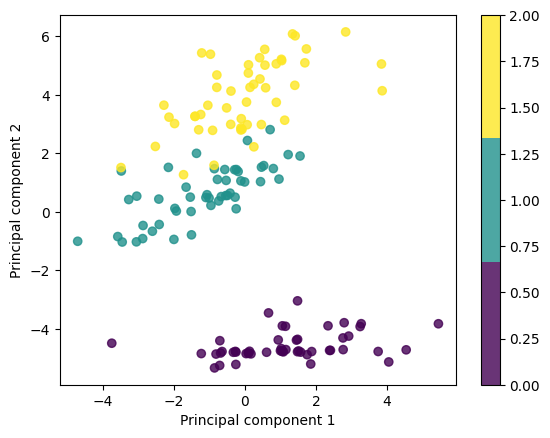

In [20]:
import matplotlib.pyplot as plt
from sklearn import datasets

data = datasets.load_iris()
X = data.data
y = data.target

pca = PCA(2)
pca.fit(X)
X_projected = pca.transform(X)

print(X.shape)
print(X_projected.shape)

plt.scatter(
    X_projected[:, 0], X_projected[:, 1], c=y, alpha=0.8, cmap=plt.cm.get_cmap('viridis',3)
)
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.colorbar()
plt.show()

# Perceptron

In [26]:
import numpy as np
from typing import Literal


def unit_step(x):
    return np.where(x > 0, 1, 0)

class Perceptron:
    def __init__(self, lr=0.01, n_iters=1000, 
                 activation_function=unit_step):
        self.lr = lr
        self.n_iters = n_iters
        self.activation_function = activation_function
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        y_ = np.where(y > 0, 1, 0)

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = x_i @ self.weights + self.bias
                y_pred = self.activation_function(linear_output)

                dw = self.lr * (y[idx] - y_pred) * x_i
                db = self.lr * (y[idx] - y_pred)

                self.weights += dw
                self.bias += db
                
    def predict(self, X):
        linear_output = X @ self.weights + self.bias
        y_pred = self.activation_function(linear_output)
        return y_pred

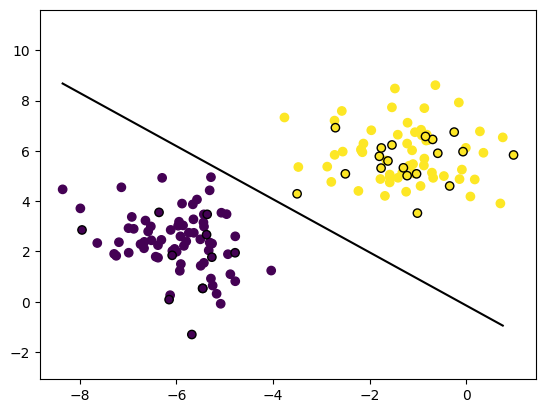

In [36]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

X, y = datasets.make_blobs(
    n_samples=150, n_features=2, cluster_std=1.05, centers=2, random_state=1234
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

p = Perceptron()
p.fit(X_train, y_train)
y_pred = p.predict(X_test)

fig, ax = plt.subplots()

x_min = X_train[:, 0].min()
x_max = X_train[:, 0].max()
x0 = np.array([x_min, x_max])
# w0 * x0 + w1 * x1 + b = 0 => x1 = (-w0 * x0 - b) / w1
w0, w1 = p.weights[0], p.weights[1]
bias = p.bias
x1 = (-w0 * x0 - bias) / w1


ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k')
ax.plot(x0, x1, 'k')

y_min = X_train[:, 1].min()
y_max = X_train[:, 1].max()
ax.set_ylim(y_min - 3, y_max + 3)

plt.show()

In [35]:
print(np.mean(y_pred == y_test))

1.0
